# Preprocesamiento para Modelado
### Sartorius Cell Instance Segmentation
---
Este notebook implementa el pipeline de preprocesamiento basado en los hallazgos del EDA:
- **606 imágenes** de tamaño uniforme 704×520 px
- **3 tipos celulares**: `astro`, `cort`, `shsy5y` con morfologías muy distintas
- **73,585 máscaras** en formato RLE
- Células desde 46 px² hasta 7,126 px² → pipeline cuidadoso con resolución

## 1. Librerías

In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"GPU : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.8.0+cu128
CUDA disponible : True
GPU : NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configuración

In [2]:
class config:
    DIRECTORY_PATH = r'C:\\Users\\Hp\\Documents\\Deep_learning\\Imagenes\\sartorius-cell-instance-segmentation'
    TRAIN_CSV      = DIRECTORY_PATH + r'\\train.csv'
    TRAIN_PATH     = DIRECTORY_PATH + r'\\train'
    TEST_PATH      = DIRECTORY_PATH + r'\\test'
    SEED           = SEED

    # Resoluciones objetivo
    # 512x512: preserva detalle para células pequeñas (mín 46 px² detectado en EDA)
    # 256x256: para pruebas rápidas (riesgo de perder células pequeñas)
    IMG_SIZE_512 = (512, 512)
    IMG_SIZE_256 = (256, 256)
    IMG_SIZE     = IMG_SIZE_512   # resolución activa

    # Normalización ImageNet (para backbones preentrenados)
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    # Split estratificado por cell_type
    VAL_FRACTION = 0.2

print(f"Resolución activa : {config.IMG_SIZE}")
print(f"Directorio        : {config.DIRECTORY_PATH}")

Resolución activa : (512, 512)
Directorio        : C:\\Users\\Hp\\Documents\\Deep_learning\\Imagenes\\sartorius-cell-instance-segmentation


## 3. Carga de datos

In [3]:
df_train = pd.read_csv(config.TRAIN_CSV)
print(f"Shape df_train : {df_train.shape}")
df_train.head()

Shape df_train : (73585, 9)


,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


In [4]:
print("Distribución de máscaras por cell_type:")
print(df_train["cell_type"].value_counts())
print(f"\nImágenes únicas: {df_train['id'].nunique()}")

Distribución de máscaras por cell_type:
cell_type
shsy5y    52286
cort      10777
astro     10522
Name: count, dtype: int64

Imágenes únicas: 606


## 4. Funciones auxiliares

In [5]:
def rle_decode(mask_rle: str, shape: tuple) -> np.ndarray:
    """
    Decodifica RLE a máscara binaria.
    mask_rle : string RLE (start length)
    shape    : (height, width)
    returns  : np.ndarray uint8 (h, w) con 0/1
    """
    s = list(map(int, mask_rle.split()))
    starts  = np.array(s[0::2]) - 1
    lengths = np.array(s[1::2])
    ends    = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, end in zip(starts, ends):
        img[start:end] = 1
    return img.reshape(shape)


def rle_encode(mask: np.ndarray) -> str:
    """Codifica máscara binaria a string RLE."""
    pixels = mask.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs   = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return ' '.join(str(r) for r in runs)


def load_image_rgb(path: str) -> np.ndarray:
    """Carga imagen en formato RGB (H, W, 3) uint8."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"No se pudo cargar: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


print("Funciones RLE y carga definidas")

Funciones RLE y carga definidas


## 5. Construcción del DataFrame por imagen

In [6]:
def build_dataframe_light(df_train, images_path):
    records = []
    for img_id, grp in tqdm(df_train.groupby("id"), desc="Indexando imágenes"):
        h         = grp["height"].iloc[0]
        w         = grp["width"].iloc[0]
        cell_type = grp["cell_type"].iloc[0]
        image_path = os.path.join(images_path, img_id + ".png")
        rles       = grp["annotation"].dropna().tolist()
        records.append({"id_imagen": img_id, "ruta_imagen": image_path,
                        "cell_type": cell_type, "width": w, "height": h,
                        "rles": rles})
    return pd.DataFrame(records)


df_img = build_dataframe_light(df_train, config.TRAIN_PATH)
print(f"df_img listo: {df_img.shape}")
df_img.head()

Indexando imágenes: 100%|██████████| 606/606 [00:00<00:00, 8455.22it/s]

df_img listo: (606, 6)


,id_imagen,ruta_imagen,cell_type,width,height,rles
0,0030fd0e6378,C:\\Users\\Hp\\Documents\\Deep_learning\\Image...,shsy5y,704,520,[118145 6 118849 7 119553 8 120257 8 120961 9 ...
1,0140b3c8f445,C:\\Users\\Hp\\Documents\\Deep_learning\\Image...,astro,704,520,[32499 3 33201 7 33902 9 34604 10 35306 11 360...
2,01ae5a43a2ab,C:\\Users\\Hp\\Documents\\Deep_learning\\Image...,cort,704,520,[241026 3 241726 9 242427 13 243130 14 243834 ...
3,026b3c2c4b32,C:\\Users\\Hp\\Documents\\Deep_learning\\Image...,cort,704,520,[170753 5 171454 12 172158 13 172862 13 173565...
4,029e5b3b89c7,C:\\Users\\Hp\\Documents\\Deep_learning\\Image...,cort,704,520,[139142 7 139845 10 140548 13 141251 15 141955...


## 6. Paso 1 — Normalización

Del EDA: histogramas RGB muestran distribución sesgada hacia bajos valores (fondo oscuro de microscopía).  
Se implementan **dos estrategias**:
- **Simple** (`/255.0`): escala a [0,1] — rápida, para modelos desde cero
- **ImageNet**: normalización estándar — necesaria con backbones preentrenados (ResNet, EfficientNet)

In [7]:
def normalize_simple(img: np.ndarray) -> np.ndarray:
    """
    Normalización simple: img / 255.0 → float32 en [0, 1]
    Equivalente a la división básica del enunciado: img = img / 255.0
    """
    return (img / 255.0).astype(np.float32)


def normalize_imagenet(img: np.ndarray,
                        mean=config.MEAN,
                        std=config.STD) -> np.ndarray:
    """
    Normalización ImageNet: (img/255 - mean) / std
    Para uso con backbones preentrenados.
    """
    img = img.astype(np.float32) / 255.0
    mean = np.array(mean, dtype=np.float32)
    std  = np.array(std,  dtype=np.float32)
    return (img - mean) / std


# Verificación
dummy = np.random.randint(0, 256, (520, 704, 3), dtype=np.uint8)
norm_simple = normalize_simple(dummy)
norm_imgnet = normalize_imagenet(dummy)

print("Normalización simple  →  min: {:.3f}  max: {:.3f}  dtype: {}".format(
    norm_simple.min(), norm_simple.max(), norm_simple.dtype))
print("Normalización ImageNet→  min: {:.3f}  max: {:.3f}  dtype: {}".format(
    norm_imgnet.min(), norm_imgnet.max(), norm_imgnet.dtype))

Normalización simple  →  min: 0.000  max: 1.000  dtype: float32
Normalización ImageNet→  min: -2.118  max: 2.640  dtype: float32


## 7. Paso 2 — Redimensionamiento

**Decisión basada en el EDA:**
- Imagen original: **704 × 520 px**
- Célula mínima detectada: **46 px²** (~7×7 px)
- `512×512`: **recomendado** — preserva detalle de células pequeñas de `cort` y `shsy5y`
- `256×256`: solo para experimentos rápidos — riesgo de perder instancias pequeñas

Las máscaras se redimensionan con **INTER_NEAREST** para preservar valores binarios exactos.

In [8]:
def resize_image(img: np.ndarray, size=config.IMG_SIZE) -> np.ndarray:
    """Redimensiona imagen. INTER_LINEAR para imágenes (suaviza bien)."""
    return cv2.resize(img, (size[1], size[0]), interpolation=cv2.INTER_LINEAR)


def resize_mask(mask: np.ndarray, size=config.IMG_SIZE) -> np.ndarray:
    """Redimensiona máscara binaria. INTER_NEAREST preserva valores 0/1."""
    return cv2.resize(mask, (size[1], size[0]), interpolation=cv2.INTER_NEAREST)


# Verificación
dummy_img  = np.random.randint(0, 256, (520, 704, 3), dtype=np.uint8)
dummy_mask = np.random.randint(0, 2,   (520, 704),    dtype=np.uint8)
r_img  = resize_image(dummy_img)
r_mask = resize_mask(dummy_mask)

print(f"Imagen original : {dummy_img.shape}  →  redimensionada: {r_img.shape}")
print(f"Máscara original: {dummy_mask.shape} →  redimensionada: {r_mask.shape}")
print(f"Valores únicos en máscara: {np.unique(r_mask)}  (debe ser [0 1])")

Imagen original : (520, 704, 3)  →  redimensionada: (512, 512, 3)
Máscara original: (520, 704) →  redimensionada: (512, 512)
Valores únicos en máscara: [0 1]  (debe ser [0 1])


## 8. Paso 3 — Conversión de máscaras: RLE → Binaria → Tensor

Pipeline por máscara:
```
RLE string → np.ndarray binario (H,W) → resize → stack → torch.Tensor (N,H,W)
```
Se genera una **máscara de instancias apilada** `(N, H, W)` donde N = número de células.

In [9]:
def rle_to_tensor(rle_list: list,
                  original_shape: tuple = (520, 704),
                  target_size: tuple = config.IMG_SIZE) -> torch.Tensor:
    """
    Convierte lista de RLE strings en tensor de máscaras de instancias.
    Retorna torch.Tensor (N, H, W) dtype=uint8
    """
    masks = []
    for rle in rle_list:
        if pd.isna(rle) or rle == '':
            continue
        m = rle_decode(rle, original_shape)        # np (H,W)
        m = resize_mask(m, size=target_size)        # np (H',W')
        masks.append(m)
    if len(masks) == 0:
        return torch.zeros((1, *target_size), dtype=torch.uint8)
    return torch.from_numpy(np.stack(masks, axis=0))


def image_to_tensor(img: np.ndarray) -> torch.Tensor:
    """np.ndarray (H,W,3) float32 → torch.Tensor (3,H,W) float32"""
    return torch.from_numpy(img.transpose(2, 0, 1))


# Verificación con RLE sintético
dummy_mask_np = np.zeros((520, 704), dtype=np.uint8)
dummy_mask_np[100:150, 200:280] = 1
dummy_rle = rle_encode(dummy_mask_np)

tensor_masks = rle_to_tensor([dummy_rle], original_shape=(520, 704))
print(f"Tensor de máscaras : shape={tensor_masks.shape}  dtype={tensor_masks.dtype}")
print(f"Valores únicos     : {torch.unique(tensor_masks).tolist()}  (debe ser [0, 1])")

dummy_f = normalize_simple(np.random.randint(0,256,(512,512,3), dtype=np.uint8))
t_img = image_to_tensor(dummy_f)
print(f"Tensor de imagen   : shape={t_img.shape}  dtype={t_img.dtype}")

Tensor de máscaras : shape=torch.Size([1, 512, 512])  dtype=torch.uint8
Valores únicos     : [0, 1]  (debe ser [0, 1])
Tensor de imagen   : shape=torch.Size([3, 512, 512])  dtype=torch.float32


## 9. Paso 4 — Data Augmentation

**Justificación desde el EDA:**
- Solo 606 imágenes → augmentation crítico para evitar overfitting
- Morfología muy distinta entre tipos celulares → augmentations geométricos aumentan variabilidad
- **Regla clave**: todos los augmentations geométricos se aplican igual a imagen Y máscaras

| Augmentation | Justificación biológica |
|---|---|
| Flip horizontal/vertical | Las células no tienen orientación preferida en microscopía |
| Rotación 90°/180°/270° | Imágenes de microscopio son isotrópicas |
| Zoom (crop aleatorio) | Simula variación de magnificación del objetivo |
| Deformación elástica (opcional) | Simula variabilidad morfológica real de membranas |

In [10]:
def random_horizontal_flip(img: np.ndarray, masks: np.ndarray, p: float = 0.5):
    """Flip horizontal consistente imagen + máscaras."""
    if random.random() < p:
        img   = np.fliplr(img).copy()
        masks = np.flip(masks, axis=2).copy()   # eje W
    return img, masks


def random_vertical_flip(img: np.ndarray, masks: np.ndarray, p: float = 0.5):
    """Flip vertical consistente imagen + máscaras."""
    if random.random() < p:
        img   = np.flipud(img).copy()
        masks = np.flip(masks, axis=1).copy()   # eje H
    return img, masks


def random_rotation_90(img: np.ndarray, masks: np.ndarray):
    """Rotación aleatoria en multiplos de 90deg. k∈{0,1,2,3} → 0,90,180,270."""
    k = random.randint(0, 3)
    img   = np.rot90(img,   k=k, axes=(0, 1)).copy()
    masks = np.rot90(masks, k=k, axes=(1, 2)).copy()
    return img, masks


def random_zoom_crop(img: np.ndarray, masks: np.ndarray,
                     scale_range=(0.8, 1.0),
                     target_size=config.IMG_SIZE):
    """
    Zoom mediante crop aleatorio + resize al tamaño destino.
    Simula variacion de magnificacion del microscopio.
    """
    H, W = img.shape[:2]
    scale = random.uniform(*scale_range)
    new_H, new_W = int(H * scale), int(W * scale)
    top  = random.randint(0, H - new_H)
    left = random.randint(0, W - new_W)

    img_crop   = img[top:top+new_H, left:left+new_W]
    masks_crop = masks[:, top:top+new_H, left:left+new_W]

    img_out = cv2.resize(img_crop, (target_size[1], target_size[0]),
                         interpolation=cv2.INTER_LINEAR)
    masks_out = np.stack([
        cv2.resize(m, (target_size[1], target_size[0]),
                   interpolation=cv2.INTER_NEAREST)
        for m in masks_crop
    ], axis=0)
    return img_out, masks_out


def elastic_deformation(img: np.ndarray, masks: np.ndarray,
                         alpha: float = 34.0, sigma: float = 4.0):
    """
    Deformacion elastica (opcional) — simula variabilidad morfologica
    de membranas celulares. Requiere scipy.
    alpha: intensidad del desplazamiento
    sigma: suavizado Gaussiano del campo de deformacion
    """
    from scipy.ndimage import gaussian_filter

    H, W = img.shape[:2]
    dx = gaussian_filter((np.random.rand(H, W) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((np.random.rand(H, W) * 2 - 1), sigma) * alpha

    x, y = np.meshgrid(np.arange(W), np.arange(H))
    map_x = np.clip(x + dx, 0, W - 1).astype(np.float32)
    map_y = np.clip(y + dy, 0, H - 1).astype(np.float32)

    img_def = cv2.remap(img, map_x, map_y,
                         interpolation=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REFLECT_101)
    masks_def = np.stack([
        cv2.remap(m, map_x, map_y,
                  interpolation=cv2.INTER_NEAREST,
                  borderMode=cv2.BORDER_REFLECT_101)
        for m in masks
    ], axis=0)
    return img_def, masks_def


print("Funciones de augmentation definidas:")
print("  · random_horizontal_flip")
print("  · random_vertical_flip")
print("  · random_rotation_90")
print("  · random_zoom_crop")
print("  · elastic_deformation (opcional)")

Funciones de augmentation definidas:
  · random_horizontal_flip
  · random_vertical_flip
  · random_rotation_90
  · random_zoom_crop
  · elastic_deformation (opcional)


## 10. Pipeline de preprocesamiento completo

Función que encadena todos los pasos en el orden correcto:
```
Carga → Decode RLE → Resize → Normalización → Augmentation (train) → Tensor
```

In [11]:
def preprocess(img_path: str,
               rle_list: list,
               target_size: tuple = config.IMG_SIZE,
               is_train: bool = True,
               use_elastic: bool = False,
               normalization: str = 'imagenet') -> dict:
    """
    Pipeline completo de preprocesamiento para Sartorius.

    Parametros
    ----------
    img_path     : ruta completa a la imagen
    rle_list     : lista de RLE strings (una por instancia celular)
    target_size  : (H, W) destino
    is_train     : si True aplica data augmentation
    use_elastic  : activa deformacion elastica (mas lento)
    normalization: 'simple' (div 255) o 'imagenet' (mean/std)

    Retorna
    -------
    dict con:
        'image' : torch.Tensor (3, H, W) float32
        'masks' : torch.Tensor (N, H, W) uint8
        'meta'  : dict con path, n_masks, size
    """
    # 1. Carga
    img = load_image_rgb(img_path)                         # (H, W, 3) uint8

    # 2. Decode RLE → stack de mascaras (N, H_orig, W_orig)
    masks_list = [rle_decode(rle, (img.shape[0], img.shape[1]))
                  for rle in rle_list if not pd.isna(rle) and rle != '']
    if len(masks_list) == 0:
        masks_np = np.zeros((1, img.shape[0], img.shape[1]), dtype=np.uint8)
    else:
        masks_np = np.stack(masks_list, axis=0)             # (N, H, W)

    # 3. Redimensionamiento
    img      = resize_image(img, size=target_size)
    masks_np = np.stack([resize_mask(m, size=target_size) for m in masks_np])

    # 4. Data augmentation (solo entrenamiento)
    if is_train:
        img, masks_np = random_horizontal_flip(img, masks_np)
        img, masks_np = random_vertical_flip(img, masks_np)
        img, masks_np = random_rotation_90(img, masks_np)
        img, masks_np = random_zoom_crop(img, masks_np, target_size=target_size)
        if use_elastic:
            img, masks_np = elastic_deformation(img, masks_np)

    # 5. Normalizacion
    if normalization == 'simple':
        img_float = normalize_simple(img)
    else:
        img_float = normalize_imagenet(img)

    # 6. Conversion a tensores
    img_tensor   = image_to_tensor(img_float)              # (3, H, W)
    masks_tensor = torch.from_numpy(masks_np)              # (N, H, W)

    return {
        'image' : img_tensor,
        'masks' : masks_tensor,
        'meta'  : {'path': img_path, 'n_masks': len(masks_list),
                   'size': target_size}
    }


print("Pipeline preprocess() definido")

Pipeline preprocess() definido


## 11. Split Train / Validación estratificado por cell_type

**Del EDA:** los 3 tipos celulares tienen morfologías radicalmente distintas:  
`astro` (área media ~803 px²) vs `shsy5y` (~287 px²) vs `cort` (~182 px²).  
Un split aleatorio podría generar data leakage de tipo celular. Se usa **stratify**.

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Usar TODO el dataframe ──────────────────────────────────────────────────
df_split = df_img.copy()

# ── Paso 1: separar Test (15%) ──────────────────────────────────────────────
df_trainval, df_test = train_test_split(
    df_split,
    test_size    = 0.15,
    stratify     = df_split['cell_type'],
    random_state = config.SEED
)

# ── Paso 2: separar Validation (15% total) ─────────────────────────────────
df_train_base, df_val = train_test_split(
    df_trainval,
    test_size    = 0.15 / 0.85,
    stratify     = df_trainval['cell_type'],
    random_state = config.SEED
)

# ── Paso 3: K-Fold sobre TRAIN ──────────────────────────────────────────────
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=config.SEED
)

folds = []

for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(df_train_base, df_train_base['cell_type'])
):

    folds.append({
        'fold'      : fold_idx,
        'train_ids' : df_train_base.iloc[train_idx]['id_imagen'].tolist(),
        'val_ids'   : df_train_base.iloc[val_idx]['id_imagen'].tolist()
    })

# ── Resumen ─────────────────────────────────────────────────────────────────
total = len(df_img)

print(f"Total imágenes : {total}")
print(f"Train base     : {len(df_train_base)} ({len(df_train_base)/total*100:.1f}%)")
print(f"Validation     : {len(df_val)} ({len(df_val)/total*100:.1f}%)")
print(f"Test           : {len(df_test)} ({len(df_test)/total*100:.1f}%)")

Total imágenes : 606
Train base     : 424 (70.0%)
Validation     : 91 (15.0%)
Test           : 91 (15.0%)


## 12. Clase Dataset PyTorch

In [13]:
class SartoriusDataset(Dataset):
    """
    Dataset de Sartorius Cell Instance Segmentation.

    Cada item retorna:
        image : torch.Tensor (3, H, W) float32  — imagen normalizada
        masks : torch.Tensor (N, H, W) uint8    — mascaras de instancias
        meta  : dict con id, cell_type, n_masks
    """
    def __init__(self, df, is_train=True,
                 target_size=config.IMG_SIZE,
                 normalization='imagenet',
                 use_elastic=False):
        
        self.df            = df.reset_index(drop=True)
        self.is_train      = is_train
        self.target_size   = target_size
        self.normalization = normalization
        self.use_elastic   = use_elastic

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        result = preprocess(
            img_path      = row['ruta_imagen'],
            rle_list      = row['rles'],
            target_size   = self.target_size,
            is_train      = self.is_train,
            use_elastic   = self.use_elastic,
            normalization = self.normalization
        )

        result['meta']['id']        = row['id_imagen']
        result['meta']['cell_type'] = row['cell_type']

        return result


# ── Datasets oficiales ──────────────────────────────────────────────────────
ds_train = SartoriusDataset(df_train_base, is_train=True)
ds_val   = SartoriusDataset(df_val,        is_train=False)
ds_test  = SartoriusDataset(df_test,       is_train=False)

# ── Verificación ────────────────────────────────────────────────────────────
sample = ds_train[0]

print("=== Verificacion SartoriusDataset ===")
print(f"image  shape : {sample['image'].shape}   dtype: {sample['image'].dtype}")
print(f"masks  shape : {sample['masks'].shape}   dtype: {sample['masks'].dtype}")
print(f"cell_type    : {sample['meta']['cell_type']}")
print(f"n_masks      : {sample['meta']['n_masks']}")

print()
print(f"Dataset train : {len(ds_train)}")
print(f"Dataset val   : {len(ds_val)}")
print(f"Dataset test  : {len(ds_test)}")

=== Verificacion SartoriusDataset ===
image  shape : torch.Size([3, 512, 512])   dtype: torch.float32
masks  shape : torch.Size([321, 512, 512])   dtype: torch.uint8
cell_type    : shsy5y
n_masks      : 321

Dataset train : 424
Dataset val   : 91
Dataset test  : 91


## 13. Entregable — Comparación visual: Original vs Procesada

Una imagen por tipo celular (`astro`, `cort`, `shsy5y`) mostrando:  
- **Izquierda (azul)**: imagen original con máscaras superpuestas  
- **Derecha (naranja)**: imagen preprocesada (512×512, normalizada, augmentation aplicado)

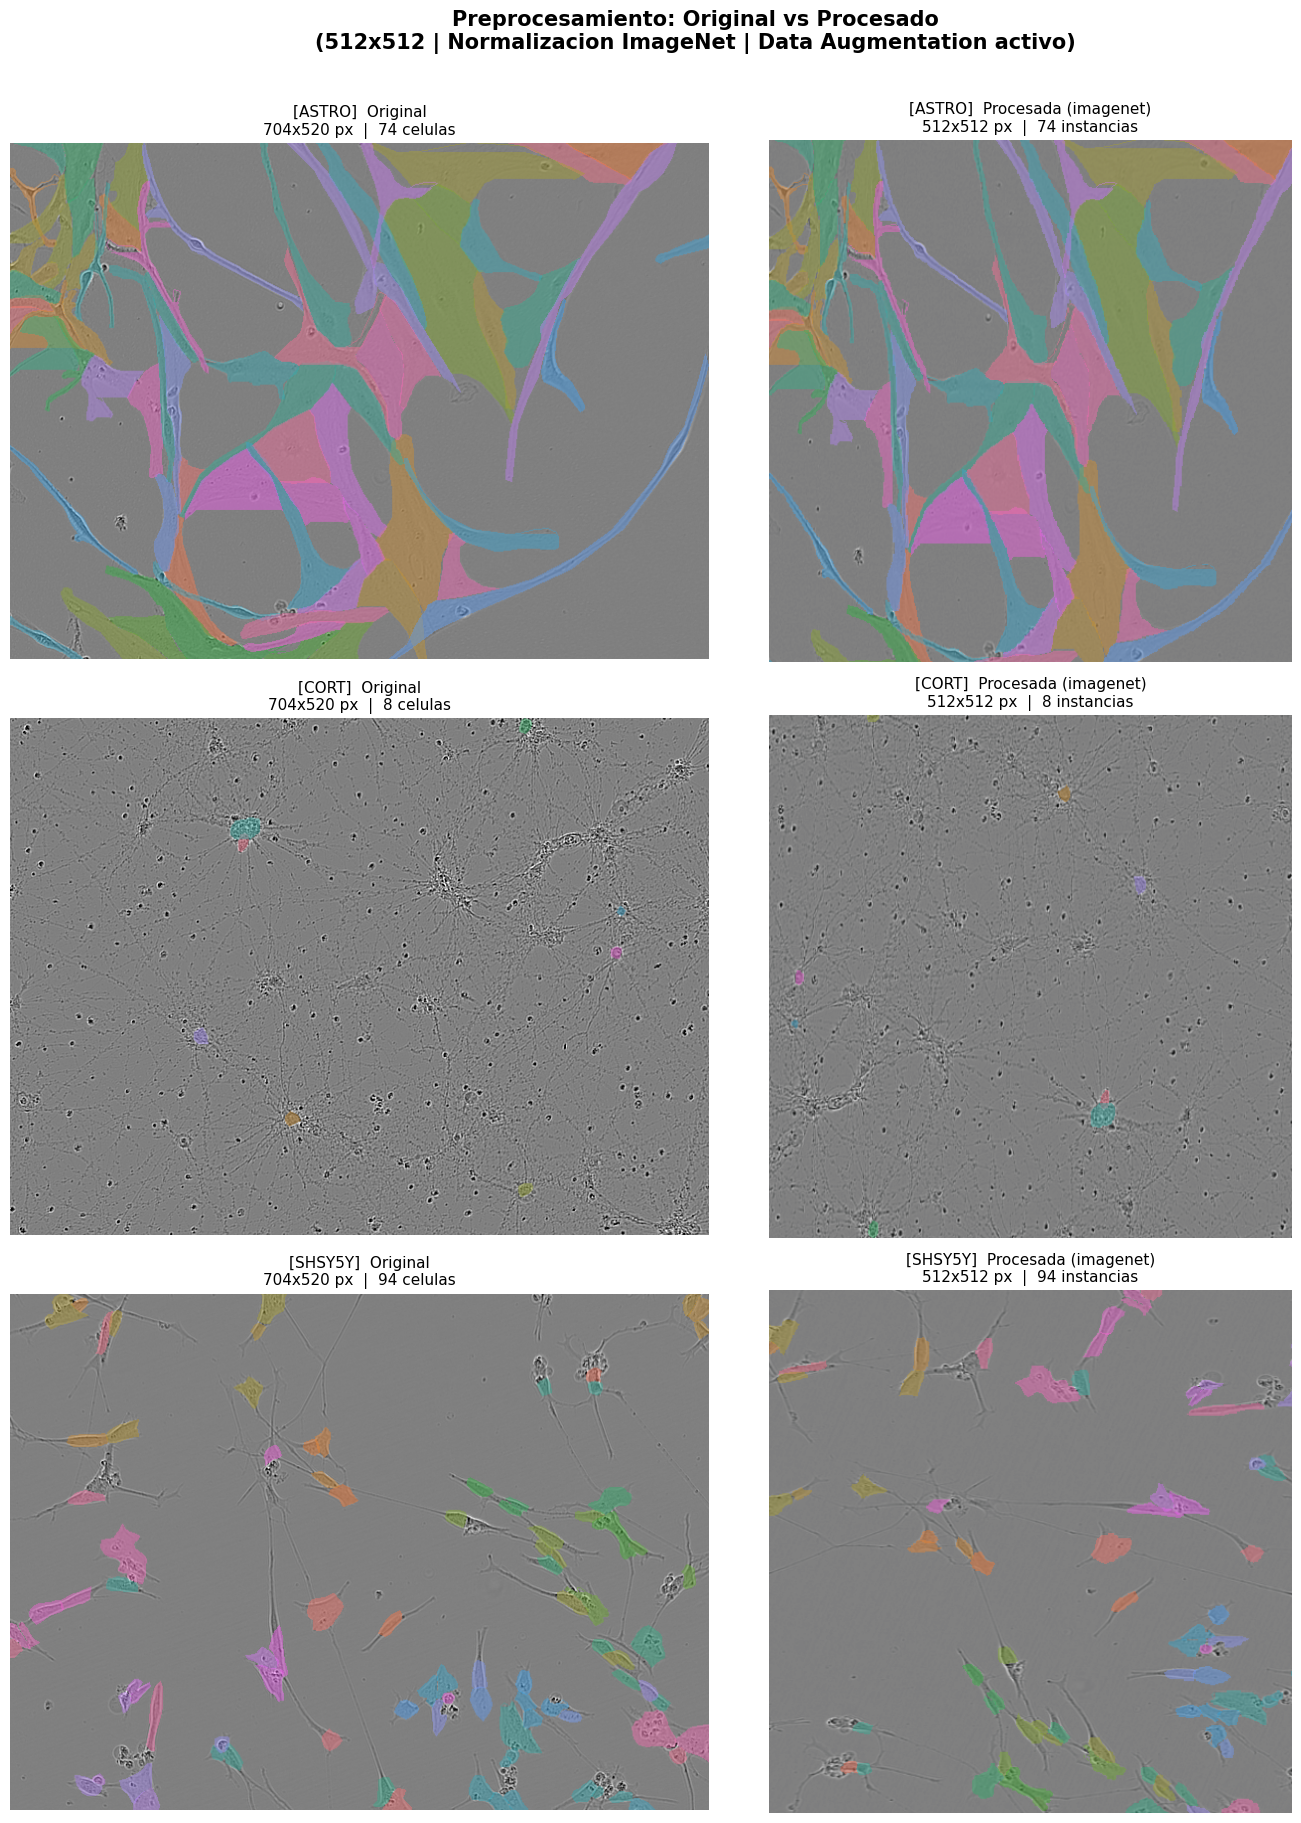

Figura guardada: preprocessing_comparison.png


In [14]:
def overlay_masks_np(img_rgb: np.ndarray, masks: np.ndarray,
                      alpha: float = 0.45) -> np.ndarray:
    """Superpone N mascaras sobre imagen RGB con colores HUSL."""
    overlay = img_rgb.copy().astype(np.float32)
    palette = sns.color_palette('husl', max(masks.shape[0], 1))
    for mask, color in zip(masks, palette):
        c = np.array(color) * 255
        overlay[mask == 1] = overlay[mask == 1] * (1 - alpha) + c * alpha
    return overlay.astype(np.uint8)


def tensor_to_display(img_tensor: torch.Tensor,
                       normalization: str = 'imagenet') -> np.ndarray:
    """Tensor (3,H,W) float32 → imagen uint8 (H,W,3) para imshow."""
    img = img_tensor.numpy().transpose(1, 2, 0)
    if normalization == 'imagenet':
        mean = np.array(config.MEAN)
        std  = np.array(config.STD)
        img  = img * std + mean
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)


# ── Figura principal ─────────────────────────────────────────────────────
NORM       = 'imagenet'
cell_types = ['astro', 'cort', 'shsy5y']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))
fig.suptitle(
    'Preprocesamiento: Original vs Procesado\n'
    '(512x512 | Normalizacion ImageNet | Data Augmentation activo)',
    fontsize=15, fontweight='bold', y=1.01
)

for row_idx, ctype in enumerate(cell_types):

    sample = df_img[df_img['cell_type'] == ctype].sample(1, random_state=SEED).iloc[0]

    # Original
    img_orig     = load_image_rgb(sample['ruta_imagen'])
    masks_orig   = np.stack([rle_decode(r, (sample['height'], sample['width']))
                             for r in sample['rles']])
    orig_overlay = overlay_masks_np(img_orig, masks_orig)

    # Procesada
    result       = preprocess(
        img_path=sample['ruta_imagen'], rle_list=sample['rles'],
        target_size=config.IMG_SIZE, is_train=True,
        use_elastic=False, normalization=NORM
    )
    img_proc     = tensor_to_display(result['image'], normalization=NORM)
    masks_proc   = result['masks'].numpy()
    proc_overlay = overlay_masks_np(img_proc, masks_proc)

    # Plot
    ax_orig, ax_proc = axes[row_idx, 0], axes[row_idx, 1]

    ax_orig.imshow(orig_overlay)
    ax_orig.set_title(
        f'[{ctype.upper()}]  Original\n'
        f'{img_orig.shape[1]}x{img_orig.shape[0]} px  |  '
        f'{masks_orig.shape[0]} celulas',
        fontsize=11
    )
    ax_orig.axis('off')

    ax_proc.imshow(proc_overlay)
    ax_proc.set_title(
        f'[{ctype.upper()}]  Procesada ({NORM})\n'
        f'{config.IMG_SIZE[1]}x{config.IMG_SIZE[0]} px  |  '
        f'{masks_proc.shape[0]} instancias',
        fontsize=11
    )
    ax_proc.axis('off')

    # Recuadro color por columna
    for ax, color in [(ax_orig, '#4e79a7'), (ax_proc, '#f28e2b')]:
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: preprocessing_comparison.png")

El pipeline de preprocesamiento logró estandarizar las imágenes hacia una resolución fija de 512×512 píxeles, aplicar normalización basada en ImageNet y realizar aumentos de datos sin comprometer la integridad morfológica ni la alineación de las máscaras de segmentación. Las estructuras celulares permanecieron claramente distinguibles tras el procesamiento, indicando que el pipeline es adecuado para el entrenamiento de modelos de segmentación profunda

## 14. Exportacion

In [15]:
import joblib
import pickle
from pathlib import Path
from datetime import datetime

# ── Directorio de exportación ────────────────────────────────────────────────
EXPORT_DIR = Path("./preprocessing_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Metadata útil para reproducibilidad ──────────────────────────────────────
metadata = {
    "created_at" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "pytorch"    : torch.__version__,
    "cuda"       : torch.cuda.is_available(),
    "device"     : torch.cuda.get_device_name(0)
                    if torch.cuda.is_available() else "cpu",
}

# ── Config serializable ──────────────────────────────────────────────────────
config_dict = {
    "IMG_SIZE"       : config.IMG_SIZE,
    "IMG_SIZE_512"   : config.IMG_SIZE_512,
    "IMG_SIZE_256"   : config.IMG_SIZE_256,

    "MEAN"           : config.MEAN,
    "STD"            : config.STD,

    "SEED"           : config.SEED,
    "VAL_FRACTION"   : config.VAL_FRACTION,

    # Paths como string
    "TRAIN_PATH"     : str(config.TRAIN_PATH),
    "TEST_PATH"      : str(config.TEST_PATH),
    "DIRECTORY_PATH" : str(config.DIRECTORY_PATH),

    # Modelado
    "DEVICE"         : "cuda" if torch.cuda.is_available() else "cpu",
    "PIN_MEMORY"     : torch.cuda.is_available(),
    "NUM_WORKERS"    : 0,
}

# ── Datos exportables ────────────────────────────────────────────────────────
export_data = {

    # DataFrames
    "df_img"         : df_img,
    "df_train_base"  : df_train_base,
    "df_val"         : df_val,
    "df_test"        : df_test,

    # Folds CV
    "folds"          : folds,

    # Configuración
    "config"         : config_dict,

    # Metadata entorno
    "metadata"       : metadata,
}

# ── 1. Export Joblib (recomendado) ───────────────────────────────────────────
joblib_path = EXPORT_DIR / "preprocessing_data.joblib"

joblib.dump(
    export_data,
    joblib_path,
    compress=3
)

print(f" Joblib guardado → {joblib_path}")
print(f"  Tamaño: {joblib_path.stat().st_size / 1e6:.2f} MB")

# ── 2. Export Pickle (backup universal) ─────────────────────────────────────
pickle_path = EXPORT_DIR / "preprocessing_data.pkl"

with open(pickle_path, "wb") as f:
    pickle.dump(
        export_data,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print(f" Pickle guardado → {pickle_path}")
print(f"  Tamaño: {pickle_path.stat().st_size / 1e6:.2f} MB")

# ── 3. CSVs separados ────────────────────────────────────────────────────────
df_img.drop(columns=["rles"], errors="ignore").to_csv(
    EXPORT_DIR / "df_img.csv",
    index=False
)

df_train_base.to_csv(
    EXPORT_DIR / "df_train.csv",
    index=False
)

df_val.to_csv(
    EXPORT_DIR / "df_val.csv",
    index=False
)

df_test.to_csv(
    EXPORT_DIR / "df_test.csv",
    index=False
)

print(f"CSVs guardados → {EXPORT_DIR}")

# ── 4. Verificación de integridad ────────────────────────────────────────────
loaded = joblib.load(joblib_path)

assert loaded["df_img"].shape == df_img.shape
assert loaded["df_train_base"].shape == df_train_base.shape
assert loaded["df_val"].shape == df_val.shape
assert loaded["df_test"].shape == df_test.shape
assert len(loaded["folds"]) == len(folds)

print("\n Verificación de integridad OK")
print(f"  df_img        : {loaded['df_img'].shape}")
print(f"  df_train_base : {loaded['df_train_base'].shape}")
print(f"  df_val        : {loaded['df_val'].shape}")
print(f"  df_test       : {loaded['df_test'].shape}")
print(f"  folds         : {len(loaded['folds'])} folds")
print(f"  device        : {loaded['config']['DEVICE']}")

 Joblib guardado → preprocessing_exports\preprocessing_data.joblib
  Tamaño: 16.50 MB
 Pickle guardado → preprocessing_exports\preprocessing_data.pkl
  Tamaño: 17.47 MB
CSVs guardados → preprocessing_exports

 Verificación de integridad OK
  df_img        : (606, 6)
  df_train_base : (424, 6)
  df_val        : (91, 6)
  df_test       : (91, 6)
  folds         : 5 folds
  device        : cuda


## 15. Resumen del pipeline

| Paso | Operacion | Detalle |
|---|---|---|
| 1 | **Normalizacion** | `img / 255.0` (simple) o `(img/255 - mean) / std` (ImageNet) |
| 2 | **Redimensionamiento** | 704×520 → 512×512 | INTER_LINEAR img / INTER_NEAREST mascaras |
| 3 | **RLE → Tensor** | RLE → binaria (H,W) → stack → Tensor (N,H,W) uint8 |
| 4 | **Augmentation** | H-flip, V-flip, rot90, zoom-crop, elastic (opcional) |
| 5 | **Split** | 80/20 estratificado por `cell_type` |

**Decisiones derivadas del EDA:**
- `512×512` elegido para preservar células de 46 px² (mínimo detectado)
- Augmentations aplicados en pareja imagen+máscara para consistencia de instancias
- Split estratificado por `cell_type` (astro/cort/shsy5y tienen morfologías muy distintas)
- 14 imágenes outlier identificadas en el EDA → considerar filtrarlas antes de entrenar